# Customer Segmentation and Review Score Prediction for Olist E-Commerce
### By Brad Wicklund

## 01. Data Wrangling

This notebook prepares the Olist Brazilian E-Commerce Public Dataset for analysis and modeling.
We will:
- Load data
- Complete data quality checks
- Convert datatypes and handle missing values
- Merge data into a unified tables when possible
- Export cleaned data

## A. Setup Notebook
First, we import necessary libraries and packages for data wrangling.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)

## B. Import data
Next, we import the raw data from the relevant csv files.

In [3]:
# Load data
customers = pd.read_csv('../data/raw/olist_customers_dataset.csv')
geolocation = pd.read_csv('../data/raw/olist_geolocation_dataset.csv')
order_items = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
order_payments = pd.read_csv('../data/raw/olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('../data/raw/olist_order_reviews_dataset.csv')
orders = pd.read_csv('../data/raw/olist_orders_dataset.csv')
products = pd.read_csv('../data/raw/olist_products_dataset.csv')
sellers = pd.read_csv('../data/raw/olist_sellers_dataset.csv')
category_translation = pd.read_csv('../data/raw/product_category_name_translation.csv')

## C. Data Quality Checks
Here we explore the data to determine the quality of the data and what cleaning might be necessary.
- Date / time columns are converted to a standard format
- Product category tranlsations are added

In [7]:
# Preview of tables
tables = {
    'customers': customers,
    'geolocation': geolocation,
    'order_items': order_items,
    'order_payments': order_payments,
    'order_reviews': order_reviews,
    'orders': orders,
    'products': products,
    'sellers': sellers,
    'category_translation': category_translation
}

for name, df in tables.items():
    print(f"\n{name} shape: {df.shape}")
    display(df.head(5))


customers shape: (99441, 5)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



geolocation shape: (1000163, 5)


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP



order_items shape: (112650, 7)


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0



sellers shape: (3095, 4)


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP



category_translation shape: (71, 2)


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [9]:
# Convert Date Columns
order_items['shipping_limit_date'] = order_items['shipping_limit_date'].apply(pd.to_datetime)

order_reviews_cols = [
    'review_creation_date', 'review_answer_timestamp'
]
order_reviews[order_reviews_cols] = order_reviews[order_reviews_cols].apply(pd.to_datetime)

orders_date_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
orders[orders_date_cols] = orders[orders_date_cols].apply(pd.to_datetime)

In [11]:
# Translate Product Categories
products = products.merge(category_translation, how='left', on='product_category_name')

In [13]:
# Add leading zeros to 4 digit zip codes
# Define the tables and column names to fix
zipcodes = [
    (customers, 'customer_zip_code_prefix'),
    (sellers, 'seller_zip_code_prefix')
]

# Loop through and fix
for x, col in zipcodes:
    x[col] = x[col].astype(str).str.zfill(5)

## D. Handling Missing Values
Missing value counts are created to evaluate any gaps in the data and various methods are used to handle these missing values.
- Normalize missing values
- Missing review titles replaced with "No title"
- Missing review messages replaced with "No comment"
- Product rows with missing dimensions are dropped

In [16]:
for name, df in tables.items():
    tables[name] = df.replace(
        to_replace=[
            r'^\s*$',            
            'null', 'NULL',
            'na', 'NA',
            'n/a', 'N/A',
            'nan', 'NaN', 'NAN'
        ],
        value=np.nan,
        regex=True
    )

In [17]:
# Check for missing values
# Create dictionary of all tables
tables = {
    'customers': customers,
    'geolocation': geolocation,
    'order_items': order_items,
    'order_payments': order_payments,
    'order_reviews': order_reviews,
    'orders': orders,
    'products': products,
    'sellers': sellers,
    'category_translation': category_translation
}

# Print missing value counts
for name, df in tables.items():
    print(f"\n{name.upper()} - Missing Values")
    display(df.isnull().sum()[df.isnull().sum() > 0])


CUSTOMERS - Missing Values


Series([], dtype: int64)


GEOLOCATION - Missing Values


Series([], dtype: int64)


ORDER_ITEMS - Missing Values


...

product_category_name            610
product_name_lenght              610
product_description_lenght       610
product_photos_qty               610
product_weight_g                   2
product_length_cm                  2
product_height_cm                  2
product_width_cm                   2
product_category_name_english    623
dtype: int64


SELLERS - Missing Values


Series([], dtype: int64)


CATEGORY_TRANSLATION - Missing Values


Series([], dtype: int64)

In [20]:
# Clean reviews
order_reviews['review_comment_title'] = order_reviews['review_comment_title'].fillna("No title")
order_reviews['review_comment_message'] = order_reviews['review_comment_message'].fillna("No comment")

In [22]:
# Drop prodcuts rows with missing physical dimensions or category
products = products.dropna(subset=[
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm',
    'product_category_name',
    'product_category_name_english'
])

In [24]:
# Check again for missing values
# Create dictionary of all tables
tables = {
    'customers': customers,
    'geolocation': geolocation,
    'order_items': order_items,
    'order_payments': order_payments,
    'order_reviews': order_reviews,
    'orders': orders,
    'products': products,
    'sellers': sellers,
    'category_translation': category_translation
}

# Print missing value counts
for name, df in tables.items():
    print(f"\n{name.upper()} - Missing Values")
    display(df.isnull().sum()[df.isnull().sum() > 0])


CUSTOMERS - Missing Values


Series([], dtype: int64)


GEOLOCATION - Missing Values


Series([], dtype: int64)


ORDER_ITEMS - Missing Values


...

Series([], dtype: int64)


SELLERS - Missing Values


Series([], dtype: int64)


CATEGORY_TRANSLATION - Missing Values


Series([], dtype: int64)

## E. Check for Duplicates
Checking tables for duplicates where a unique ID should be present.

In [27]:
orders['order_id'].duplicated().sum()
customers['customer_id'].duplicated().sum()
products['product_id'].duplicated().sum()
sellers['seller_id'].duplicated().sum()

0

## F. Merge Tables

In [30]:
order_items_merged = order_items.merge(products, on='product_id', how='left')

## G. Check for Outliers

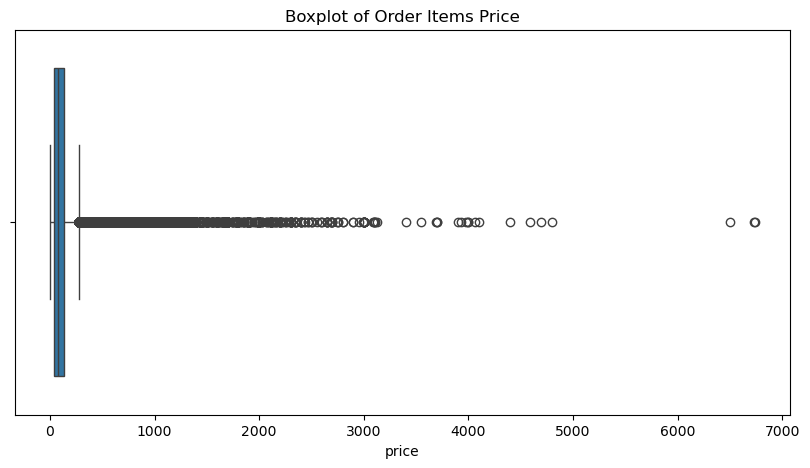

In [33]:
# Check order items price for outliers
plt.figure(figsize=(10, 5))
sns.boxplot(x=order_items_merged['price'])
plt.title('Boxplot of Order Items Price')
plt.show()

In [35]:
order_items_merged['price'].describe()

count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

In [37]:
Q1 = order_items_merged['price'].quantile(0.25)
Q3 = order_items_merged['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = order_items_merged[order_items_merged['price'] > upper_bound]
print(f"Number of outliers: {outliers.shape[0]}")

Number of outliers: 8427


In [39]:
outliers.sort_values('price', ascending=False).head(10)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
3556,0812eb902a67711a1cb742b3cdaa65ae,1,489ae2aa008f021502940f251d4cce7f,e3b4998c7a498169dc7bce44e6bb6277,2017-02-16 20:37:36,6735.00,194.31,utilidades_domesticas,31.0,875.0,2.0,30000.0,60.0,61.0,33.0,housewares
112233,fefacc66af859508bf1a7934eab1e97f,1,69c590f7ffc7bf8db97190b6cb6ed62e,80ceebb4ee9b31afb6c6a916a574a1e2,2018-08-02 04:05:13,6729.00,193.21,pcs,50.0,1935.0,4.0,5660.0,54.0,18.0,47.0,computers
107841,f5136e38d1a14a4dbd87dff67da82701,1,1bdf5e6731585cf01aa8169c7028d6ad,ee27a8f15b1dded4d213a468ba4eb391,2017-06-15 02:45:17,6499.00,227.66,artes,28.0,3954.0,2.0,7400.0,47.0,25.0,25.0,art
74336,a96610ab360d42a2e5335a3998b4718a,1,a6492cc69376c469ab6f61d8f44de961,59417c56835dd8e2e72f91f809cd4092,2017-04-18 13:25:18,4799.00,151.34,eletroportateis,41.0,1780.0,2.0,22600.0,55.0,40.0,40.0,small_appliances
11249,199af31afc78c699f0dbf71fb178d4d4,1,c3ed642d592594bb648ff4a04cee2747,59417c56835dd8e2e72f91f809cd4092,2017-05-09 15:50:15,4690.00,74.34,eletroportateis,59.0,2217.0,2.0,30000.0,50.0,49.0,50.0,small_appliances
62086,8dbc85d1447242f3b127dda390d56e19,1,259037a6a41845e455183f89c5035f18,c72de06d72748d1a0dfb2125be43ba63,2018-06-28 12:36:36,4590.00,91.78,pcs,55.0,1710.0,2.0,2900.0,35.0,10.0,40.0,computers
29193,426a9742b533fc6fed17d1fd6d143d7e,1,a1beef8f3992dbd4cd8726796aa69c53,512d298ac2a96d1931b6bd30aa21f61d,2018-08-16 14:24:28,4399.87,113.45,instrumentos_musicais,59.0,944.0,3.0,3550.0,71.0,34.0,22.0,musical_instruments
45843,68101694e5c5dc7330c91e1bbc36214f,1,6cdf8fc1d741c76586d8b6b15e9eef30,ed4acab38528488b65a9a9c603ff024a,2018-04-05 08:27:27,4099.99,75.27,consoles_games,59.0,3172.0,1.0,3050.0,34.0,10.0,22.0,consoles_games
78310,b239ca7cd485940b31882363b52e6674,1,dd113cb02b2af9c8e5787e8f1f0722f6,821fb029fc6e495ca4f08a35d51e53a5,2018-08-02 08:15:14,4059.00,104.51,esporte_lazer,51.0,1511.0,1.0,8000.0,55.0,25.0,45.0,sports_leisure
59137,86c4eab1571921a6a6e248ed312f5a5a,1,6902c1962dd19d540807d0ab8fade5c6,fa1c13f2614d7b5c4749cbc52fecda94,2017-03-23 20:08:04,3999.90,17.01,relogios_presentes,53.0,1773.0,2.0,800.0,16.0,11.0,11.0,watches_gifts


Price outliers appear to be in luxury or high cost categories.  For this reason we will not make any changes to these data points.

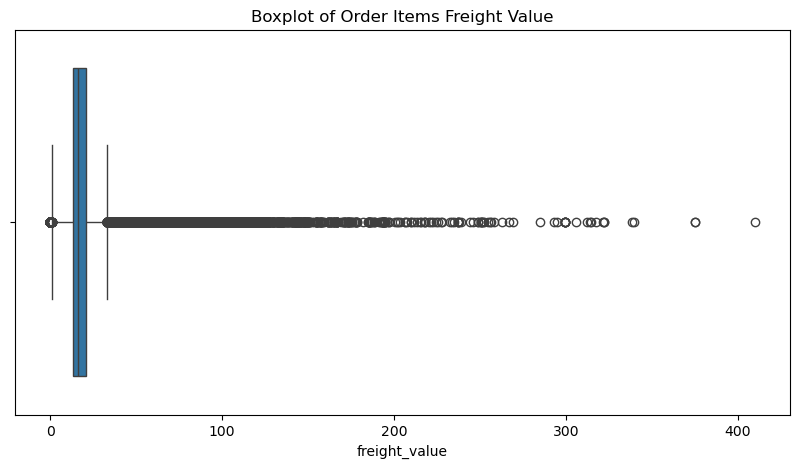

In [42]:
# Check Order Items Freight Values for outliers
plt.figure(figsize=(10, 5))
sns.boxplot(x=order_items_merged['freight_value'])
plt.title('Boxplot of Order Items Freight Value')
plt.show()

In [44]:
order_items_merged['freight_value'].describe()

count    112650.000000
mean         19.990320
std          15.806405
min           0.000000
25%          13.080000
50%          16.260000
75%          21.150000
max         409.680000
Name: freight_value, dtype: float64

In [46]:
Q1 = order_items_merged['freight_value'].quantile(0.25)
Q3 = order_items_merged['freight_value'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = order_items_merged[order_items_merged['freight_value'] > upper_bound]
print(f"Number of outliers: {outliers.shape[0]}")

Number of outliers: 11613


In [48]:
outliers.sort_values('freight_value', ascending=False).head(10)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
73486,a77e1550db865202c56b19ddc6dc4d53,1,ec31d2a17b299511e7c8627be9337b9b,257e61d3251fb5efb9daadddbc2cf7ca,2018-04-25 06:55:13,979.00,409.68,bebes,44.0,385.0,6.0,14675.0,55.0,64.0,52.0,baby
3303,076d1555fb53a89b0ef4d529e527a0f6,1,a3cd9517ebf5a50dca25acce54f3b171,6fa9202c10491e472dffd59a3e82b2a3,2018-08-07 04:35:22,2338.08,375.28,utilidades_domesticas,52.0,1910.0,4.0,30000.0,75.0,58.0,65.0,housewares
28044,3fde74c28a3d5d618c00f26d51baafa0,1,a3cd9517ebf5a50dca25acce54f3b171,6fa9202c10491e472dffd59a3e82b2a3,2018-08-22 03:15:09,2338.08,375.28,utilidades_domesticas,52.0,1910.0,4.0,30000.0,75.0,58.0,65.0,housewares
69797,9f49bd16053df810384e793386312674,1,256a9c364b75753b97bee410c9491ad8,5c030029b5916fed0986310385ec9009,2018-08-02 03:44:28,1149.00,339.59,utilidades_domesticas,59.0,649.0,1.0,25250.0,68.0,66.0,66.0,housewares
16731,264a7e199467906c0727394df82d1a6a,1,97c948ebc8c04b26b7bbb095d4228f2a,17f51e7198701186712e53a39c564617,2018-04-23 17:15:10,1050.00,338.30,beleza_saude,60.0,554.0,1.0,30000.0,55.0,75.0,61.0,health_beauty
87936,c7a07ddd52bbe18b61da49a8d89853d3,1,97c948ebc8c04b26b7bbb095d4228f2a,17f51e7198701186712e53a39c564617,2018-07-31 10:45:11,1050.00,322.10,beleza_saude,60.0,554.0,1.0,30000.0,55.0,75.0,61.0,health_beauty
5037,0b6230647ed16f4b3e70282dc4b5b87f,1,46e24ce614899e36617e37ea1e4aa6ff,17f51e7198701186712e53a39c564617,2018-06-01 19:14:24,1050.00,321.88,beleza_saude,58.0,549.0,1.0,30000.0,55.0,75.0,61.0,health_beauty
3584,0822bcde10bb5d023755a71bc8f7797f,1,363a9f5b97bf194da23858be722a7aa5,9596c870880d900012f2e8e6e30d06d7,2018-05-10 23:52:39,990.00,321.46,construcao_ferramentas_construcao,44.0,1455.0,6.0,30000.0,100.0,50.0,50.0,construction_tools_construction
29787,43bdbd9dc0931d72befdf4765af6c442,1,7e53e051875b2a0c9f22acd8a9a29a20,eeb6de78f79159600292e314a77cbd18,2018-07-12 08:35:21,3089.00,317.47,industria_comercio_e_negocios,56.0,508.0,1.0,11300.0,44.0,34.0,25.0,industry_commerce_and_business
48320,6ddfbf514959b49b6410c01ad93054bb,1,363a9f5b97bf194da23858be722a7aa5,9596c870880d900012f2e8e6e30d06d7,2017-11-30 15:10:57,1045.00,314.40,construcao_ferramentas_construcao,44.0,1455.0,6.0,30000.0,100.0,50.0,50.0,construction_tools_construction


Freight value outliers appear to be either heavier or larger packages.  For this reason we will not make any changes to this data.

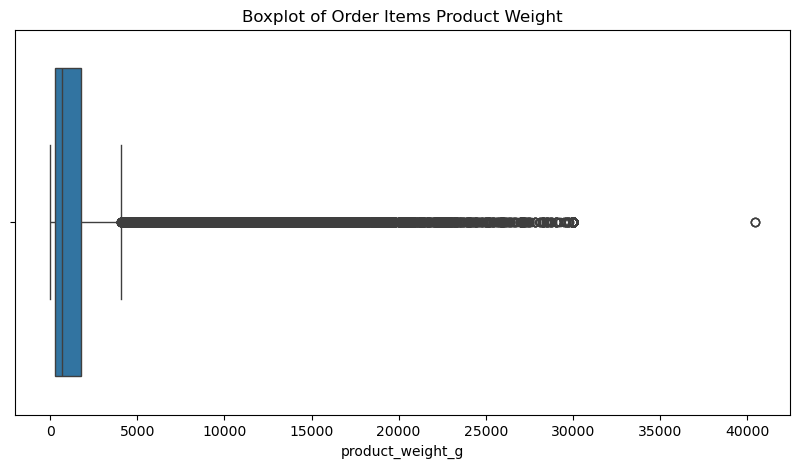

In [51]:
# Check Order Items Product Weight for outliers
plt.figure(figsize=(10, 5))
sns.boxplot(x=order_items_merged['product_weight_g'])
plt.title('Boxplot of Order Items Product Weight')
plt.show()

In [53]:
order_items_merged['product_weight_g'].describe()

count    111022.000000
mean       2099.897507
std        3754.972723
min           0.000000
25%         300.000000
50%         700.000000
75%        1800.000000
max       40425.000000
Name: product_weight_g, dtype: float64

In [55]:
Q1 = order_items_merged['product_weight_g'].quantile(0.25)
Q3 = order_items_merged['product_weight_g'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = order_items_merged[order_items_merged['product_weight_g'] > upper_bound]
print(f"Number of outliers: {outliers.shape[0]}")

Number of outliers: 15661


In [57]:
outliers.sort_values('product_weight_g', ascending=False).head(10)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
48753,6ecf1a4051b4c5ed613624b460970a26,1,26644690fde745fc4654719c3904e1db,1835b56ce799e6a4dc4eddc053f04066,2017-11-23 08:55:48,80.0,12.06,cama_mesa_banho,59.0,534.0,1.0,40425.0,13.0,65.0,28.0,bed_bath_table
32763,4a45f9f66971302cf881ecfa142f42ba,1,26644690fde745fc4654719c3904e1db,1835b56ce799e6a4dc4eddc053f04066,2017-12-29 19:13:20,80.0,16.32,cama_mesa_banho,59.0,534.0,1.0,40425.0,13.0,65.0,28.0,bed_bath_table
63982,9223919b300f6989e1715333fca0d6ce,1,26644690fde745fc4654719c3904e1db,1835b56ce799e6a4dc4eddc053f04066,2018-03-07 23:15:32,80.0,16.32,cama_mesa_banho,59.0,534.0,1.0,40425.0,13.0,65.0,28.0,bed_bath_table
52136,76a34d13a444dc9e514d59482291ba07,2,0ed9a84687fad2d921b09b0ebcc4cded,17f51e7198701186712e53a39c564617,2018-01-03 19:21:37,680.0,85.25,beleza_saude,53.0,423.0,1.0,30000.0,55.0,75.0,61.0,health_beauty
22805,340bd726abb7b57850b8f3e93c52a559,1,aed75ad669fbebd5a385ac7cc2ae7573,17f51e7198701186712e53a39c564617,2018-04-26 05:50:26,550.0,78.37,beleza_saude,42.0,427.0,1.0,30000.0,50.0,75.0,56.0,health_beauty
52408,7748e0d22cb39dacfbbe50ab2cb768fa,1,ebf1c13032246ea801765e8cb5417365,cb41bfbcbda0aea354a834ab222f9a59,2017-12-04 09:31:08,399.0,54.33,casa_construcao,39.0,1190.0,2.0,30000.0,50.0,80.0,50.0,home_construction
47317,6b8c62c594c79c27167d9337676cd93a,1,97194fdae68fa163b7cc5c02bfedbf16,05f51e13da97139648b8125c31e5f51b,2018-03-29 10:55:31,499.9,78.93,bebes,51.0,1202.0,4.0,30000.0,81.0,50.0,50.0,baby
74428,a997ce452b12e113ccd903fd9323d382,1,363a9f5b97bf194da23858be722a7aa5,9596c870880d900012f2e8e6e30d06d7,2017-12-14 13:10:59,1045.0,177.94,construcao_ferramentas_construcao,44.0,1455.0,6.0,30000.0,100.0,50.0,50.0,construction_tools_construction
52452,7769fd866a4a22e50c08f6dcdeb462b7,1,8b7a9eed0d30c43346eb8de2d821b2fb,cd843d4cf8ef32827de0396605163ba3,2017-08-23 00:05:41,289.0,81.92,moveis_cozinha_area_de_servico_jantar_e_jardim,48.0,314.0,1.0,30000.0,32.0,95.0,67.0,kitchen_dining_laundry_garden_furniture
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop


Product weight outliers appear to be larger items.  For this reason we will not make any changes to this data.

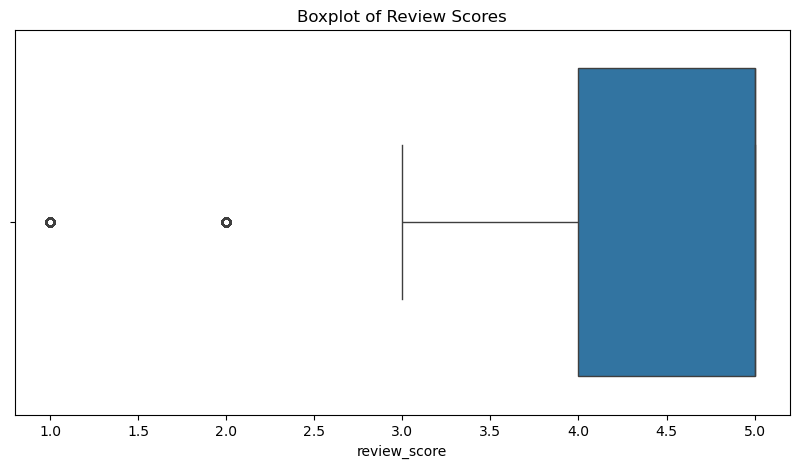

In [60]:
# Check Review Scores for outliers
plt.figure(figsize=(10, 5))
sns.boxplot(x=order_reviews['review_score'])
plt.title('Boxplot of Review Scores')
plt.show()

In [62]:
order_reviews['review_score'].describe()

count    99224.000000
mean         4.086421
std          1.347579
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: review_score, dtype: float64

In [64]:
Q1 = order_reviews['review_score'].quantile(0.25)
Q3 = order_reviews['review_score'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = order_reviews[order_reviews['review_score'] > upper_bound]
print(f"Number of outliers: {outliers.shape[0]}")

Number of outliers: 0


There are no review score outliers to address.

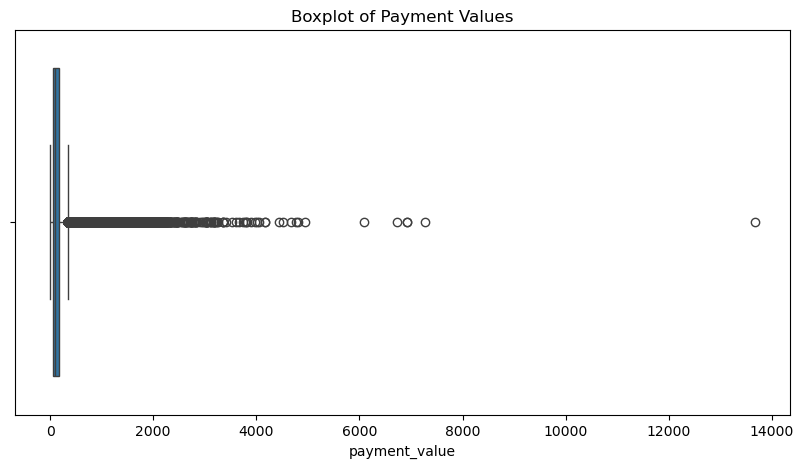

In [67]:
# Check Payment Value for outliers
plt.figure(figsize=(10, 5))
sns.boxplot(x=order_payments['payment_value'])
plt.title('Boxplot of Payment Values')
plt.show()

## H. Dealing with Big Data
At ~104k rows, there are no expected memory issues while working this data.  No additional measures are needed at this time to work with the data set.  The largest table is the geolocation data, which has over 1 million rows, but this will not be used for most of our computations.

The largest table in our dataset is the geolocation table with over 1 million records.  As our customer and seller tables already include zipcode prefix, city and state, we will be excluding the geolocation data from the rest of our project to avoid adding unnecessary complexity to our project.

## G. Export Cleaned Data

In [77]:
from pathlib import Path

processed_path = Path("../data/processed")
processed_path.mkdir(parents=True, exist_ok=True)

tables = {
    'customers': customers,
    'geolocation': geolocation,
    'order_items': order_items,
    'order_payments': order_payments,
    'order_reviews': order_reviews,
    'orders': orders,
    'products': products,
    'sellers': sellers,
    'category_translation': category_translation
}

for name, df in tables.items():
    csv_path = processed_path / f"{name}_clean.csv"
    df.to_csv(csv_path, index=False)
    print(f"Saved {name} to {csv_path}")

Saved customers to ../data/processed/customers_clean.csv
Saved geolocation to ../data/processed/geolocation_clean.csv
Saved order_items to ../data/processed/order_items_clean.csv
Saved order_payments to ../data/processed/order_payments_clean.csv
Saved order_reviews to ../data/processed/order_reviews_clean.csv
Saved orders to ../data/processed/orders_clean.csv
Saved products to ../data/processed/products_clean.csv
Saved sellers to ../data/processed/sellers_clean.csv
Saved category_translation to ../data/processed/category_translation_clean.csv
